In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Load Data

In [3]:
train = pd.read_csv("train.csv", parse_dates=["date"])
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv", parse_dates=["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv("transactions.csv", parse_dates=["date"])

In [4]:
# Display the first few rows of each dataset
print("Train Dataset:")
print(train.head())
print("\nStores Dataset:")
print(stores.head())
print("\nOil Dataset:")
print(oil.head())
print("\nHolidays Dataset:")
print(holidays.head())
print("\nTransactions Dataset:")
print(transactions.head())


Train Dataset:
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

Stores Dataset:
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

Oil Dataset:
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20


In [5]:
# clean hoildays 
holidays = holidays[holidays['transferred'] == False]

holidays = holidays.groupby('date')['type'].first().reset_index()

holidays = holidays.rename(columns={'type': 'holiday_type'})

# 2) Merge everything


In [6]:
df = train.copy()

# Merge stores
df = df.merge(stores, on='store_nbr', how='left')

# Merge transactions
df = df.merge(transactions, on=['date', 'store_nbr'], how='left')

# Merge oil
df = df.merge(oil, on='date', how='left')

# Merge holidays (after cleaning it before)
df = df.merge(holidays, on='date', how='left')


In [7]:
# 3) Check shape 
print("Train shape before merge:", train.shape)
print("After merge shape:", df.shape)

Train shape before merge: (3000888, 6)
After merge shape: (3000888, 13)


# 3) Cleaning

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  transactions  float64       
 11  dcoilwtico    float64       
 12  holiday_type  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(5)
memory usage: 297.6+ MB


In [9]:
df.isnull().mean() * 100

id               0.000000
date             0.000000
store_nbr        0.000000
family           0.000000
sales            0.000000
onpromotion      0.000000
city             0.000000
state            0.000000
type             0.000000
cluster          0.000000
transactions     8.190376
dcoilwtico      30.938242
holiday_type    85.570071
dtype: float64

In [ ]:
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()

# Transactions → no transactions = 0
df['transactions'] = df['transactions'].fillna(0)

# Holidays → no holiday
df['holiday_type'] = df['holiday_type'].fillna('None')

# Sort 
df = df.sort_values(['store_nbr', 'family', 'date'])


df = df.drop_duplicates()

print("After cleaning:", df.shape)

After cleaning: (3000888, 13)


In [11]:
df.isnull().mean() * 100

id              0.0
date            0.0
store_nbr       0.0
family          0.0
sales           0.0
onpromotion     0.0
city            0.0
state           0.0
type            0.0
cluster         0.0
transactions    0.0
dcoilwtico      0.0
holiday_type    0.0
dtype: float64

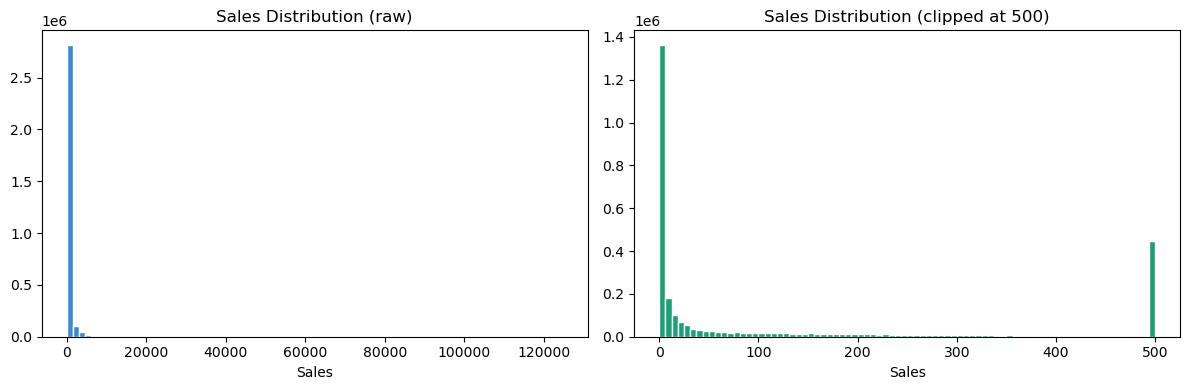

Sales > 1000: 268599 rows (8.95%)
Strategy: keep all — RMSLE penalises under-prediction more than over-prediction


In [12]:
# ── 3c. Outlier Check ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['sales'], bins=80, color='#3B8BD4', edgecolor='white')
axes[0].set_title('Sales Distribution (raw)')
axes[0].set_xlabel('Sales')

axes[1].hist(train['sales'].clip(upper=500), bins=80, color='#1D9E75', edgecolor='white')
axes[1].set_title('Sales Distribution (clipped at 500)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()

print(f'Sales > 1000: {(train["sales"] > 1000).sum()} rows ({(train["sales"] > 1000).mean()*100:.2f}%)')
print('Strategy: keep all — RMSLE penalises under-prediction more than over-prediction')

# 2) Feature Engineering


In [13]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # Date & Time Features 
    df['month']         = df['date'].dt.month
    df['day']           = df['date'].dt.day
    df['day_of_week']   = df['date'].dt.dayofweek
    df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
    df['quarter']       = df['date'].dt.quarter

    
    df['trend'] = (df['date'] - df['date'].min()).dt.days

    # ── Domain Knowledge Features ─────────────────────────
    df['is_holiday'] = (df['holiday_type'] != 'None').astype(int)

    # Promotion 
    df['onpromotion'] = df['onpromotion'].fillna(0)

    df['is_payday'] = df['day'].isin([15, 30]).astype(int)

    # ── Lag & Rolling Features ────────────────────────────
    if is_train:
        df = df.sort_values(['store_nbr', 'family', 'date'])

        grp = df.groupby(['store_nbr', 'family'])['sales']

        df['sales_lag_1']  = grp.shift(1)

        for lag in [7, 14, 28]:
            df[f'sales_lag_{lag}'] = grp.shift(lag)

        # Rolling
        for window in [7, 28]:
            df[f'sales_roll_mean_{window}'] = (
                grp.shift(1).rolling(window).mean()
            )
            df[f'sales_roll_std_{window}'] = (
                grp.shift(1).rolling(window).std()
            )

        df['promo_lag_interaction'] = df['onpromotion'] * df['sales_lag_7']

        df = df.dropna()

    else:
        lag_cols = [
            'sales_lag_1','sales_lag_7','sales_lag_14','sales_lag_28',
            'sales_roll_mean_7','sales_roll_mean_28',
            'sales_roll_std_7','sales_roll_std_28',
            'promo_lag_interaction'
        ]
        for col in lag_cols:
            df[col] = 0

    return df

# 3) train / Validation Split

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [15]:
train_df = train[train['date'] < '2017-01-01']
test_df  = train[train['date'] >= '2017-01-01']

In [16]:
X_train = train_df.drop(columns=['sales', 'date', 'id'])
y_train = train_df['sales']

X_test = test_df.drop(columns=['sales', 'date', 'id'])
y_test = test_df['sales']

##  Preprocessing (Pipeline)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols   = X_train.select_dtypes(exclude='object').columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # 🔥 هنا الصح
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [20]:
# =========================
# Imports
# =========================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# =========================
# Reduce data size to speed up training
train_sample = train.sample(300000, random_state=42).sort_values('date')

train_df = train_sample[train_sample['date'] < '2017-01-01']
test_df  = train_sample[train_sample['date'] >= '2017-01-01']

X_train = train_df.drop(columns=['sales', 'date', 'id'])
y_train = train_df['sales']

X_test = test_df.drop(columns=['sales', 'date', 'id'])
y_test = test_df['sales']

# =========================
# Models 
# =========================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),

    # Faster Random Forest
    'Random Forest (fast)': RandomForestRegressor(
        n_estimators=50,   
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    #  Best fast model for large data
    'Hist Gradient Boosting': HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

# =========================
# Training + Evaluation
# =========================
results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessing', preprocessing),
        ('model', model)
    ])
    
    print(f"\nTraining {name}...")
    

    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    # =========================
    # Metrics 
    # =========================
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
   
    mask = y_test != 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    }
    
    print(f"{name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2: {r2:.4f}")

# =========================
# Results Table
# =========================
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='RMSE')

print("\nFinal Comparison:")
print(results_df)


Training Linear Regression...
Linear Regression
RMSE: 869.7207
MAE: 274.7184
MAPE: 433.16%
R2: 0.5758

Training Ridge Regression...
Ridge Regression
RMSE: 869.7326
MAE: 274.7220
MAPE: 433.17%
R2: 0.5758

Training Random Forest (fast)...
Random Forest (fast)
RMSE: 494.8695
MAE: 176.1811
MAPE: 556.98%
R2: 0.8627

Training Hist Gradient Boosting...


c:\Users\Asus\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Asus\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Asus\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

Hist Gradient Boosting
RMSE: 501.7789
MAE: 171.5265
MAPE: 442.66%
R2: 0.8588

Final Comparison:
                              RMSE         MAE    MAPE (%)        R2
Random Forest (fast)    494.869532  176.181060  556.984402  0.862653
Hist Gradient Boosting  501.778943  171.526456  442.661004  0.858791
Linear Regression       869.720726  274.718356  433.160157  0.575774
Ridge Regression        869.732597  274.721951  433.172134  0.575762


In [21]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "12"

## Train an Improved Random Forest Model

In [22]:

best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

best_pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('model', best_model)
])

# Train
best_pipe.fit(X_train, y_train)

# Predict
y_pred = best_pipe.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Improved RF RMSE:", rmse)
print("Improved RF R2:", r2)

Improved RF RMSE: 482.1247581758959
Improved RF R2: 0.8696362593066403


In [23]:
from sklearn.metrics import mean_absolute_error

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MAPE (exclude zeros)
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

# R²
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")

RMSE: 482.1248
MAE: 156.2608
MAPE: 406.82%
R2: 0.8696


In [ ]:
import pandas as pd

# Access trained model
rf_model = best_pipe.named_steps['model']

# Get feature importances
importances = rf_model.feature_importances_

feature_names = X_train.columns  

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances[:len(feature_names)]
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))

       feature  importance
0    store_nbr    0.314872
1       family    0.109866
2  onpromotion    0.000000


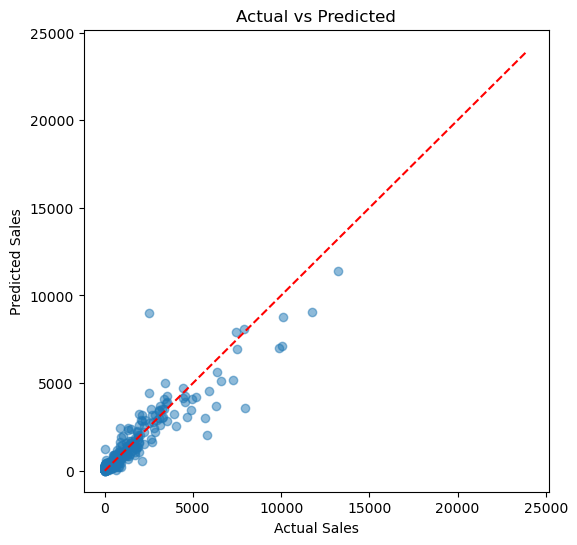

In [25]:
# Sample for visualization
sample_idx = np.random.choice(len(y_test), 1000, replace=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test.iloc[sample_idx], y_pred[sample_idx], alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.show()

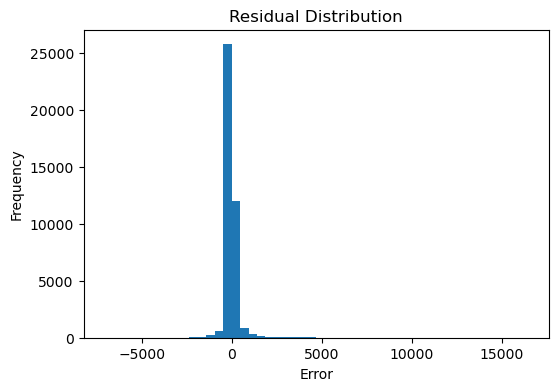

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [27]:
rf_model = best_pipe.named_steps['model']

importances = rf_model.feature_importances_

print(importances[:10])

[0.31487217 0.10986578 0.         0.         0.         0.12708936
 0.         0.00343366 0.         0.02684189]


In [28]:
# Predict on test set
y_pred = best_pipe.predict(X_test)

# Show sample results
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results_df.head(10)

,Actual,Predicted
0,0.0,190.710040
1,0.0,394.256437
2,0.0,156.397898
3,0.0,19.471680
4,0.0,996.040112
5,0.0,175.311871
6,0.0,19.471680
7,0.0,19.471680
8,0.0,19.471680
9,0.0,1533.922637


In [29]:
sample = X_test.iloc[[0]] # Take the first row as a sample

prediction = best_pipe.predict(sample)

print("Predicted sales:", prediction[0])

Predicted sales: 190.71004005053


In [31]:
sample_batch = X_test.iloc[:5]

predictions = best_pipe.predict(sample_batch)

print( "Predicted sales:" + str(predictions) )

Predicted sales:[190.71004005 394.25643671 156.39789812  19.47167966 996.04011182]


In [32]:
test_predictions = best_pipe.predict(X_test)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sales_prediction': test_predictions
})

submission.head()

,id,sales_prediction
2597586,2597586,190.710040
2597884,2597884,394.256437
2597176,2597176,156.397898
2597825,2597825,19.471680
2597751,2597751,996.040112


In [33]:
import joblib

joblib.dump(best_pipe, 'sales_model.pkl')

['sales_model.pkl']

In [39]:
import subprocess
import threading

def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.headless", "true"])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

print("Streamlit is running at: http://localhost:8501")


Streamlit is running at: http://localhost:8501


In [1]:
import sklearn
print(sklearn.__version__)

1.7.2
